### Project Title
- Student Attendance Analysis and Certification System
### Problem Statement
- Managing attendance and certification eligibility for a large number of students manually is time-consuming and error-prone.
### Objectives
* Automate attendance calculation.
* Identify certified and non-certified students.
* Visualize attendance patterns.
* Use Machine Learning for classification.
### Tools & Technologies
* Python
* Jupyter Notebook
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
### Methodology
1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Building
6. Model Evaluation
### Algorithms Used
#### 1. Logistic Regression

* Used for binary classification.
* Predicts whether a student is Certified or Not Certified based on attendance.

#### 2. Decision Tree Classifier

* Creates decision rules based on attendance data.
* Easy to interpret and visualize.
### Results

* Number of Certified Students
* Number of Not Certified Students
* Accuracy of Logistic Regression
* Accuracy of Decision Tree
* Accuracy of Random Forest
* Accuracy of KNN

### Conclusion

The Attendance Certification System successfully automates certification decisions based on attendance criteria. By applying Machine Learning algorithms such as Logistic Regression, Decision Tree, Random Forest, and KNN, the system efficiently classifies students as Certified or Not Certified, reduces manual effort, improves accuracy, and provides valuable insights through data visualization.


### Objective
Predict whether a student is:
- certified(Attendance >= 32 sessions)
- not certified(Attendance < 32 sessions)

For:
- 980 students
- 40 sessions/classes

In [ ]:
### importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## generating attendance data(creating sample data)
import pandas as pd
import numpy as np

np.random.seed(42)

students = [f"STD{i}" for i in range(1,981)]

data = {"Student_ID": students}

for session in range(1,41):
    data[f"Session{session}"] = np.random.choice(
        ["P","A"],
        size=980,
        p=[0.8,0.2]
    )

df = pd.DataFrame(data)

df

,Student_ID,Session1,Session2,Session3,Session4,Session5,Session6,Session7,Session8,Session9,...,Session31,Session32,Session33,Session34,Session35,Session36,Session37,Session38,Session39,Session40
0,STD1,P,P,P,P,A,P,P,P,P,...,P,P,A,A,P,A,P,P,A,P
1,STD2,A,P,P,P,P,P,P,A,P,...,P,P,P,P,P,P,P,P,P,P
2,STD3,P,P,A,P,P,P,P,A,P,...,A,A,P,P,P,P,A,P,A,P
3,STD4,P,P,P,P,P,P,A,P,P,...,A,A,P,P,P,A,A,A,P,P
4,STD5,P,P,P,P,A,A,P,P,A,...,P,P,P,P,P,A,A,P,P,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,STD976,P,A,P,P,P,P,P,P,P,...,P,A,A,P,A,P,A,P,P,P
976,STD977,P,P,P,P,P,A,P,P,P,...,P,P,A,P,P,P,P,P,A,P
977,STD978,P,P,P,P,P,P,P,P,P,...,P,P,A,P,P,A,P,P,P,P
978,STD979,P,P,A,P,P,P,A,P,P,...,P,P,P,P,P,A,P,A,A,P


In [ ]:
df.shape

(980, 41)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 41 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Student_ID  980 non-null    str  
 1   Session1    980 non-null    str  
 2   Session2    980 non-null    str  
 3   Session3    980 non-null    str  
 4   Session4    980 non-null    str  
 5   Session5    980 non-null    str  
 6   Session6    980 non-null    str  
 7   Session7    980 non-null    str  
 8   Session8    980 non-null    str  
 9   Session9    980 non-null    str  
 10  Session10   980 non-null    str  
 11  Session11   980 non-null    str  
 12  Session12   980 non-null    str  
 13  Session13   980 non-null    str  
 14  Session14   980 non-null    str  
 15  Session15   980 non-null    str  
 16  Session16   980 non-null    str  
 17  Session17   980 non-null    str  
 18  Session18   980 non-null    str  
 19  Session19   980 non-null    str  
 20  Session20   980 non-null    str  
 21  Sess

In [ ]:
df.head()

,Student_ID,Session1,Session2,Session3,Session4,Session5,Session6,Session7,Session8,Session9,...,Session31,Session32,Session33,Session34,Session35,Session36,Session37,Session38,Session39,Session40
0,STD1,P,P,P,P,A,P,P,P,P,...,P,P,A,A,P,A,P,P,A,P
1,STD2,A,P,P,P,P,P,P,A,P,...,P,P,P,P,P,P,P,P,P,P
2,STD3,P,P,A,P,P,P,P,A,P,...,A,A,P,P,P,P,A,P,A,P
3,STD4,P,P,P,P,P,P,A,P,P,...,A,A,P,P,P,A,A,A,P,P
4,STD5,P,P,P,P,A,A,P,P,A,...,P,P,P,P,P,A,A,P,P,A


In [ ]:
df.duplicated().sum()
df

,Student_ID,Session1,Session2,Session3,Session4,Session5,Session6,Session7,Session8,Session9,...,Session31,Session32,Session33,Session34,Session35,Session36,Session37,Session38,Session39,Session40
0,STD1,P,P,P,P,A,P,P,P,P,...,P,P,A,A,P,A,P,P,A,P
1,STD2,A,P,P,P,P,P,P,A,P,...,P,P,P,P,P,P,P,P,P,P
2,STD3,P,P,A,P,P,P,P,A,P,...,A,A,P,P,P,P,A,P,A,P
3,STD4,P,P,P,P,P,P,A,P,P,...,A,A,P,P,P,A,A,A,P,P
4,STD5,P,P,P,P,A,A,P,P,A,...,P,P,P,P,P,A,A,P,P,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,STD976,P,A,P,P,P,P,P,P,P,...,P,A,A,P,A,P,A,P,P,P
976,STD977,P,P,P,P,P,A,P,P,P,...,P,P,A,P,P,P,P,P,A,P
977,STD978,P,P,P,P,P,P,P,P,P,...,P,P,A,P,P,A,P,P,P,P
978,STD979,P,P,A,P,P,P,A,P,P,...,P,P,P,P,P,A,P,A,A,P


In [ ]:
df=df.drop_duplicates()
df

,Student_ID,Session1,Session2,Session3,Session4,Session5,Session6,Session7,Session8,Session9,...,Session31,Session32,Session33,Session34,Session35,Session36,Session37,Session38,Session39,Session40
0,STD1,P,P,P,P,A,P,P,P,P,...,P,P,A,A,P,A,P,P,A,P
1,STD2,A,P,P,P,P,P,P,A,P,...,P,P,P,P,P,P,P,P,P,P
2,STD3,P,P,A,P,P,P,P,A,P,...,A,A,P,P,P,P,A,P,A,P
3,STD4,P,P,P,P,P,P,A,P,P,...,A,A,P,P,P,A,A,A,P,P
4,STD5,P,P,P,P,A,A,P,P,A,...,P,P,P,P,P,A,A,P,P,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,STD976,P,A,P,P,P,P,P,P,P,...,P,A,A,P,A,P,A,P,P,P
976,STD977,P,P,P,P,P,A,P,P,P,...,P,P,A,P,P,P,P,P,A,P
977,STD978,P,P,P,P,P,P,P,P,P,...,P,P,A,P,P,A,P,P,P,P
978,STD979,P,P,A,P,P,P,A,P,P,...,P,P,P,P,P,A,P,A,A,P


In [ ]:
attendance_cols = df.columns[1:]

df[attendance_cols] = df[attendance_cols].replace({
    "P":1,
    "A":0
})
df.head()

,Student_ID,Session1,Session2,Session3,Session4,Session5,Session6,Session7,Session8,Session9,...,Session31,Session32,Session33,Session34,Session35,Session36,Session37,Session38,Session39,Session40
0,STD1,1,1,1,1,0,1,1,1,1,...,1,1,0,0,1,0,1,1,0,1
1,STD2,0,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
2,STD3,1,1,0,1,1,1,1,0,1,...,0,0,1,1,1,1,0,1,0,1
3,STD4,1,1,1,1,1,1,0,1,1,...,0,0,1,1,1,0,0,0,1,1
4,STD5,1,1,1,1,0,0,1,1,0,...,1,1,1,1,1,0,0,1,1,0


In [ ]:
df["Total_Attendance"] = df[attendance_cols].sum(axis=1)

df.head()

,Student_ID,Session1,Session2,Session3,Session4,Session5,Session6,Session7,Session8,Session9,...,Session32,Session33,Session34,Session35,Session36,Session37,Session38,Session39,Session40,Total_Attendance
0,STD1,1,1,1,1,0,1,1,1,1,...,1,0,0,1,0,1,1,0,1,29
1,STD2,0,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,35
2,STD3,1,1,0,1,1,1,1,0,1,...,0,1,1,1,1,0,1,0,1,29
3,STD4,1,1,1,1,1,1,0,1,1,...,0,1,1,1,0,0,0,1,1,32
4,STD5,1,1,1,1,0,0,1,1,0,...,1,1,1,1,0,0,1,1,0,25


### where:
- 1 = Certified
- 0 = not certified


In [ ]:
df["Certification_Status"] = np.where(
    df["Total_Attendance"] >= 32,
    1,
    0
)
df

,Student_ID,Session1,Session2,Session3,Session4,Session5,Session6,Session7,Session8,Session9,...,Session33,Session34,Session35,Session36,Session37,Session38,Session39,Session40,Total_Attendance,Certification_Status
0,STD1,1,1,1,1,0,1,1,1,1,...,0,0,1,0,1,1,0,1,29,0
1,STD2,0,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,35,1
2,STD3,1,1,0,1,1,1,1,0,1,...,1,1,1,1,0,1,0,1,29,0
3,STD4,1,1,1,1,1,1,0,1,1,...,1,1,1,0,0,0,1,1,32,1
4,STD5,1,1,1,1,0,0,1,1,0,...,1,1,1,0,0,1,1,0,25,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,STD976,1,0,1,1,1,1,1,1,1,...,0,1,0,1,0,1,1,1,33,1
976,STD977,1,1,1,1,1,0,1,1,1,...,0,1,1,1,1,1,0,1,33,1
977,STD978,1,1,1,1,1,1,1,1,1,...,0,1,1,0,1,1,1,1,34,1
978,STD979,1,1,0,1,1,1,0,1,1,...,1,1,1,0,1,0,0,1,30,0


In [ ]:
df["Certification_Status"].value_counts()

Certification_Status
1    576
0    404
Name: count, dtype: int64

### Visualization

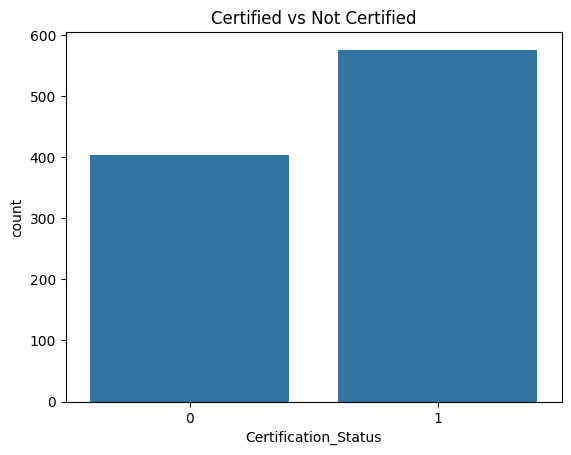

In [ ]:
sns.countplot(
    x="Certification_Status",
    data=df
)

plt.title("Certified vs Not Certified")
plt.show()

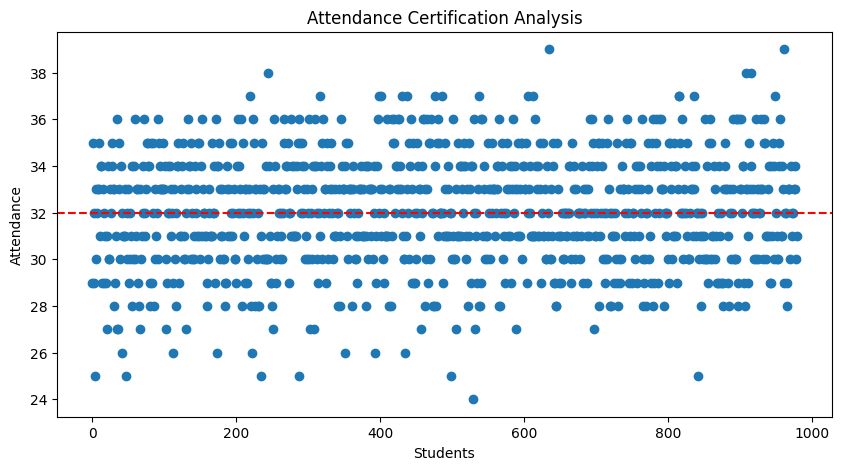

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(
    range(len(df)),
    df["Total_Attendance"]
)

plt.axhline(
    y=32,
    color="red",
    linestyle="--"
)

plt.xlabel("Students")
plt.ylabel("Attendance")
plt.title("Attendance Certification Analysis")

plt.show()

In [ ]:
X = df[attendance_cols]
X

,Session1,Session2,Session3,Session4,Session5,Session6,Session7,Session8,Session9,Session10,...,Session31,Session32,Session33,Session34,Session35,Session36,Session37,Session38,Session39,Session40
0,1,1,1,1,0,1,1,1,1,1,...,1,1,0,0,1,0,1,1,0,1
1,0,1,1,1,1,1,1,0,1,0,...,1,1,1,1,1,1,1,1,1,1
2,1,1,0,1,1,1,1,0,1,1,...,0,0,1,1,1,1,0,1,0,1
3,1,1,1,1,1,1,0,1,1,1,...,0,0,1,1,1,0,0,0,1,1
4,1,1,1,1,0,0,1,1,0,0,...,1,1,1,1,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,1,0,1,1,1,1,1,1,1,1,...,1,0,0,1,0,1,0,1,1,1
976,1,1,1,1,1,0,1,1,1,0,...,1,1,0,1,1,1,1,1,0,1
977,1,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,0,1,1,1,1
978,1,1,0,1,1,1,0,1,1,1,...,1,1,1,1,1,0,1,0,0,1


In [ ]:
y = df["Certification_Status"]
y

0      0
1      1
2      0
3      1
4      0
      ..
975    1
976    1
977    1
978    0
979    0
Name: Certification_Status, Length: 980, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Decision Tree Algorithm

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(
    X_train,
    y_train
)
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1])

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1])

In [ ]:
df["Certification_Status"].value_counts()

Certification_Status
1    576
0    404
Name: count, dtype: int64

### This means:
- 576 Certified students
- 404 Not Certified students

### Predicting a student

In [ ]:
X = df[['Total_Attendance']]
y = df['Certification_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
new_student = pd.DataFrame({
    "Total_Attendance": [35]
})

prediction = dt.predict(new_student)

print("Prediction:", prediction[0])

Prediction: 1
